# 06 · K-Means Clustering (unsupervised cross-check)

The rule-based segments in notebook 02 are business-driven. Here we let the data speak: cluster customers on **log-transformed, standardized** R/F/M and compare the clusters to the rule-based segments.

Log transform tames the heavy right skew in Frequency/Monetary; standardization puts the three axes on equal footing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv("../Data/Processed/rfm_scored_segments.csv")
X = rfm[["Recency","Frequency","Monetary"]].copy()
X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)
X_scaled.shape

(4320, 3)

### Choose k with the elbow + silhouette

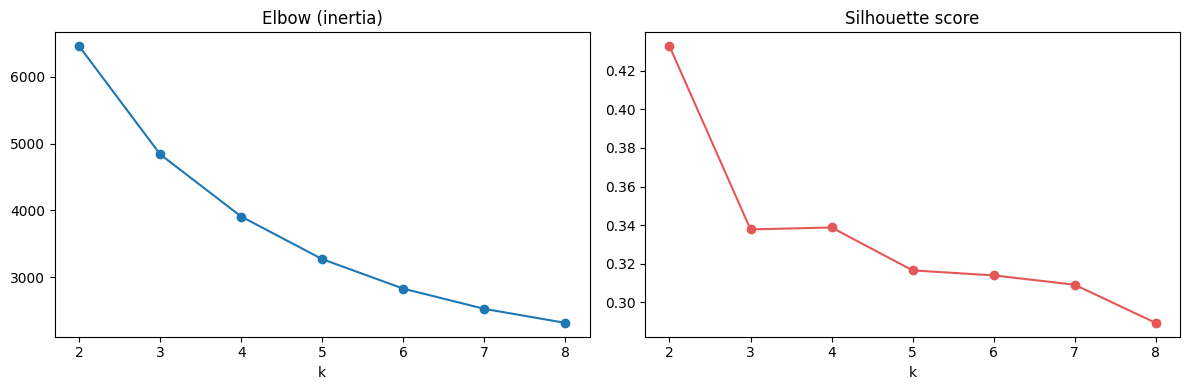

k=2  silhouette=0.433
k=3  silhouette=0.338
k=4  silhouette=0.339
k=5  silhouette=0.317
k=6  silhouette=0.314
k=7  silhouette=0.309
k=8  silhouette=0.289


In [2]:
inertia, sil = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(list(K), inertia, "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(K), sil, "o-", color="#E45756"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout()
Path("../Reports/Figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../Reports/Figures/kmeans_selection.png", dpi=200); plt.show()
for k, s in zip(K, sil): print(f"k={k}  silhouette={s:.3f}")

### Fit final model and profile the clusters

In [3]:
k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
rfm["Cluster"] = km.labels_

profile = (rfm.groupby("Cluster")
           .agg(Customers=("CustomerID","count"),
                Avg_Recency=("Recency","mean"),
                Avg_Frequency=("Frequency","mean"),
                Avg_Monetary=("Monetary","mean"),
                Total_Revenue=("Monetary","sum"))
           .round(2).sort_values("Avg_Monetary", ascending=False))
profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
1,685,11.79,13.96,7733.87,5297698.28
3,1185,67.51,4.15,1672.49,1981904.94
0,828,18.06,2.12,526.40,435863.02
2,1622,182.97,1.32,341.66,554171.08


### How do data-driven clusters line up with the rule-based segments?

In [4]:
ct = pd.crosstab(rfm["Cluster"], rfm["Segment"])
print(ct)
rfm.to_csv("../Data/Processed/rfm_kmeans.csv", index=False)
print("\nSaved ../Data/Processed/rfm_kmeans.csv")

Segment  About to Sleep  At Risk  Cant Lose Them  Champions  Hibernating  \
Cluster                                                                    
0                     0        0               0        174            0   
1                     0        4               1        651            0   
2                   338      359              19          0          609   
3                     0      340              58        341            0   

Segment  Loyal Customers  New Customers  Potential Loyalists  Promising  
Cluster                                                                  
0                    335             68                  209         42  
1                     29              0                    0          0  
2                     42              2                    2        251  
3                    446              0                    0          0  

Saved ../Data/Processed/rfm_kmeans.csv
